#Resampling and Simulation
* Implement a bootstrap (for mean, proportion, or model)
* Explain what the variability in your results means

Research Question: Is there a credible difference between the mean GPA of scholarship students and non-scholarship students in the wider student population


A single boostrap is implemented to perform a hypothesis test.

H0: There is no difference between mean GPA of scholarship and nonscholarship students

Ha: There is a difference between mean GPA of scholarship and nonscholarship students

After bootstrapping to simulate different groups of students from the original sample, the mean GPA between scholar and nonscholarships students are compared for each set, then form a 95% confidence interval to determine if there is a significance.

In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/prepared_student_data.csv")
scholar = df[df['scholarship_Yes']==1]['cumulative_gpa'].reset_index(drop=True)
nonscholar = df[df['scholarship_Yes']==0]['cumulative_gpa'].reset_index(drop=True)

n_scholar=len(scholar)
n_nonscholar=len(nonscholar)
iterations=1000
rng=np.random.default_rng(2478)
means=np.full(iterations,np.nan)
for i in range(iterations):
  idx_s=rng.integers(0,n_scholar,size=n_scholar)
  idx_ns=rng.integers(0,n_nonscholar,size=n_nonscholar)

  mean_s=scholar.iloc[idx_s].mean()
  mean_ns=nonscholar.iloc[idx_ns].mean()
  means[i]=mean_s-mean_ns
ci=np.percentile(means,[2.5,97.5])
print(f"Confidence Interval: {ci}")

[-0.02319369  0.15744843]


Average GPA Difference: 0.07002069580233262


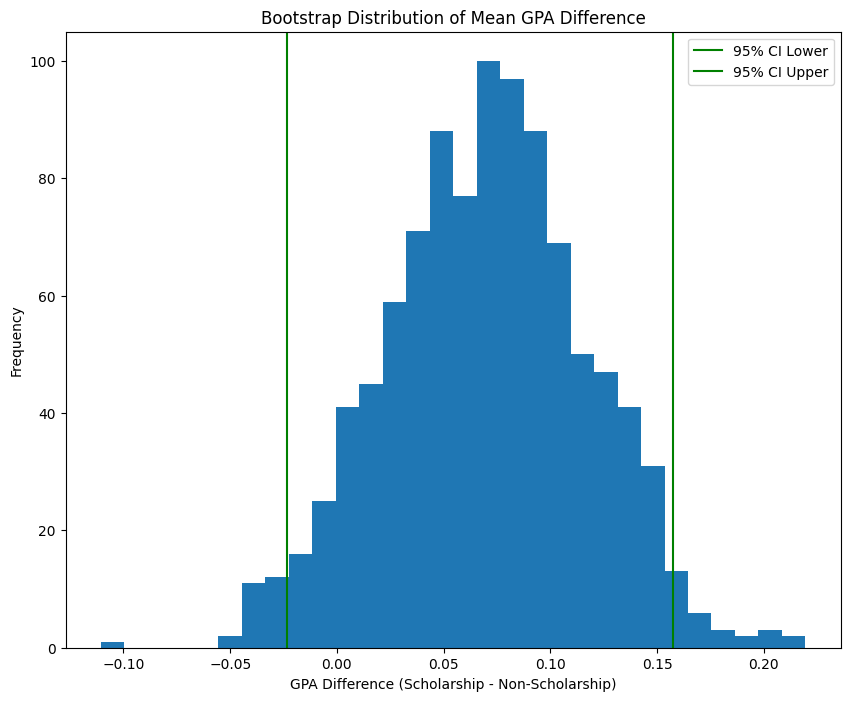

In [16]:
import matplotlib.pyplot as plt

print(f"Average GPA Difference: {means.mean()}")
plt.figure(figsize=(10,8))
plt.hist(means,bins=30)
plt.axvline(ci[0], color='green', label='95% CI Lower')
plt.axvline(ci[1], color='green', label='95% CI Upper')
plt.title('Bootstrap Distribution of Mean GPA Difference')
plt.xlabel('GPA Difference (Scholarship - Non-Scholarship)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

##Interpretation

With confidence intervals, if 0 is contained in the interval, it means there is no statistically significant difference. The interval of -0.0232 and 0.157 contains 0, meaning we fail to reject H0 and there is no statistical significance between GPAs of scholarship and nonscholarship students.

The variability in the results represents the overall uncertainty in the model. Here, the dataset only provides a snapshot of the overall national or global student population.
